In [51]:
%cd ..

/Users/rubenmarcus/Desktop/Code/Personal Projects/Deep Hedging


In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset, DataLoader

from src.models.gbm import simulate_gbm
from src.derivatives.european_call import black_scholes_call, black_scholes_delta
from src.strategies.delta_hedge import run_delta_hedge
from src.strategies.neural_hedge import NeuralHedge
from src.portfolio import run_hedge_torch
from src.train import fit, collect_pnl
from src.metrics import mse_hedging_loss

In [53]:
DTYPE = torch.float32
SEED = 123
MODEL_SEED = 456

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")

elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")

else:
    device = torch.device("cpu")

print("device:", device)

device: mps


In [54]:
# experiment params

S0 = 100.0
K = 100.0

sigma = 0.20

r = 0.0
T = 1.0

n_steps = 52


# training params

n_train = 50_000
n_val = 10_000
n_test = 50_000

batch_size = 1024

n_epochs = 50

learning_rate = 1e-3

In [55]:
# 0, 5, 10, 20, 100 bps
cost_rates = [0.0, 0.0005, 0.0010, 0.0020, 0.0100]

In [56]:
train_paths_np = simulate_gbm(
    S0=S0,
    sigma=sigma,
    T=T,
    n_steps=n_steps,
    n_paths=n_train,
    r=r,
    seed=123
).spot

val_paths_np = simulate_gbm(
    S0=S0,
    sigma=sigma,
    T=T,
    n_steps=n_steps,
    n_paths=n_val,
    r=r,
    seed=456
).spot

test_paths_np = simulate_gbm(
    S0=S0,
    sigma=sigma,
    T=T,
    n_steps=n_steps,
    n_paths=n_test,
    r=r,
    seed=789
).spot

train_dataset = TensorDataset(torch.tensor(train_paths_np, dtype=DTYPE))
val_dataset = TensorDataset(torch.tensor(val_paths_np, dtype=DTYPE))
test_dataset = TensorDataset(torch.tensor(test_paths_np, dtype=DTYPE))

print(train_paths_np.shape)
print(val_paths_np.shape)
print(test_paths_np.shape)

(50000, 53)
(10000, 53)
(50000, 53)


In [57]:
def make_loaders(seed=SEED):
    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, val_loader, test_loader

In [58]:
premium = black_scholes_call(
    S=S0,
    K=K,
    sigma=sigma,
    T=T,
    t=0.0,
    r=r
)

print("initial call premium:", premium)

initial call premium: 7.965567455405804


In [59]:
def make_run_batch(transaction_cost_rate):
    def run_batch(model, batch):
        (spot_paths,) = batch
        spot_paths = spot_paths.to(device=device, dtype=DTYPE)

        variance_paths = torch.full_like(spot_paths, sigma**2)

        result = run_hedge_torch(
            model=model,
            spot_paths=spot_paths,
            variance_paths=variance_paths,
            K=K,
            T=T,
            premium=premium,
            r=r,
            transaction_cost_rate=transaction_cost_rate
        )

        return result["pnl"]

    return run_batch


In [60]:
def make_model():
    torch.manual_seed(MODEL_SEED)
    model = NeuralHedge(hidden_dim=64)

    return model.to(device)

In [61]:
trained_models = {}
training_histories = {}

for c in cost_rates:
    print(f"\ntraining c = {c:.4%}")

    train_loader, val_loader, _ = make_loaders()
    model = make_model()

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    run_batch = make_run_batch(transaction_cost_rate=c)

    history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        loss_fn=mse_hedging_loss,
        run_batch=run_batch,
        n_epochs=n_epochs
    )

    trained_models[c] = model
    training_histories[c] = pd.DataFrame(history)



training c = 0.0000%

training c = 0.0500%

training c = 0.1000%

training c = 0.2000%

training c = 1.0000%


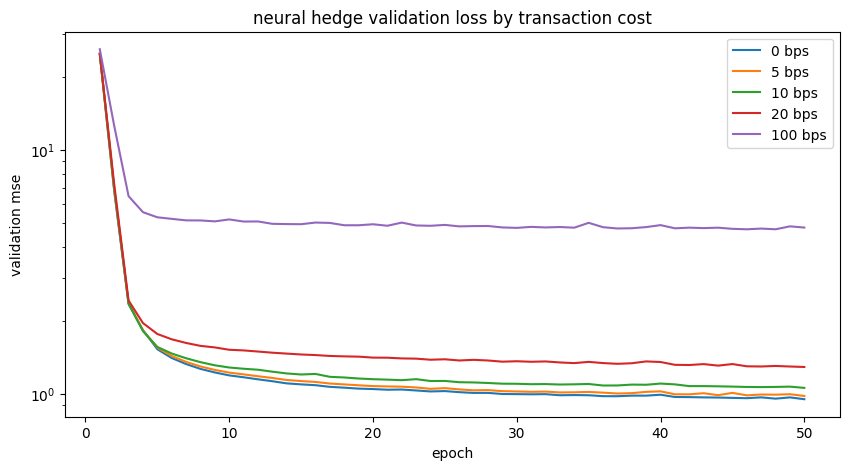

In [62]:
plt.figure(figsize=(10, 5))

for c in cost_rates:
    history = training_histories[c]

    plt.plot(
        history["epoch"],
        history["val_loss"],
        label=f"{c * 10_000:.0f} bps"
    )

plt.yscale("log")

plt.xlabel("epoch")
plt.ylabel("validation mse")
plt.title("neural hedge validation loss by transaction cost")

plt.legend()
plt.show()

In [63]:
@torch.no_grad()
def collect_neural_results(
    model,
    loader,
    transaction_cost_rate
):
    model.eval()

    pnl_batches = []
    cost_batches = []
    share_turnover_batches = []
    notional_turnover_batches = []

    for (spot_paths,) in loader:
        spot_paths = spot_paths.to(device=device, dtype=DTYPE)
        variance_paths = torch.full_like(spot_paths, sigma**2)

        result = run_hedge_torch(
            model=model,
            spot_paths=spot_paths,
            variance_paths=variance_paths,
            K=K,
            T=T,
            premium=premium,
            r=r,
            transaction_cost_rate=transaction_cost_rate
        )

        pnl_batches.append(result["pnl"].cpu())
        cost_batches.append(result["transaction_costs"].cpu())
        share_turnover_batches.append(result["share_turnover"].cpu())
        notional_turnover_batches.append(result["notional_turnover"].cpu())

    return {
        "pnl": torch.cat(pnl_batches).numpy(),
        "transaction_costs": torch.cat(cost_batches).numpy(),
        "share_turnover": torch.cat(share_turnover_batches).numpy(),
        "notional_turnover": torch.cat(notional_turnover_batches).numpy(),
    }

In [64]:
_, _, test_loader = make_loaders()

neural_results = {}

for c in cost_rates:
    neural_results[c] = collect_neural_results(
        model=trained_models[c],
        loader=test_loader,
        transaction_cost_rate=c
    )

In [65]:
bs_results = {}

for c in cost_rates:
    result = run_delta_hedge(
        stock_paths=test_paths_np,
        K=K,
        sigma=sigma,
        T=T,
        r=r,
        transaction_cost_rate=c,
        record_history=False
    )

    bs_results[c] = result

In [66]:
def pnl_metrics(pnl):
    pnl = np.asarray(pnl)

    return {
        "mean_pnl": np.mean(pnl),
        "std_pnl": np.std(pnl, ddof=1),
        "rmse": np.sqrt(np.mean(pnl**2)),
        "q05": np.quantile(pnl, 0.05),
        "q01": np.quantile(pnl, 0.01)
    }

def full_metrics(result):
    metrics = pnl_metrics(result["pnl"])
    metrics.update({
        "mean_tc": np.mean(result["transaction_costs"]),
        "mean_share_turnover": np.mean(result["share_turnover"]),
        "mean_notional_turnover": np.mean(result["notional_turnover"])
    })

    return metrics

In [67]:
records = []

for c in cost_rates:
    nn_metrics = full_metrics(neural_results[c])

    records.append({
        "strategy": "neural",
        "cost_rate": c,
        "cost_bps": c * 10_000,
        **nn_metrics,
    })

    bs_metrics = full_metrics(bs_results[c])

    records.append({
        "strategy": "black-scholes delta",
        "cost_rate": c,
        "cost_bps": c * 10_000,
        **bs_metrics
    })

results_df = pd.DataFrame(records)

results_df

,strategy,cost_rate,cost_bps,mean_pnl,std_pnl,rmse,q05,q01,mean_tc,mean_share_turnover,mean_notional_turnover
0,neural,0.0000,0.0,0.003130,0.979398,0.979393,-1.606773,-2.659002,0.000000,2.854724,284.440002
1,black-scholes delta,0.0000,0.0,0.000034,0.951395,0.951385,-1.552763,-2.599678,0.000000,2.805728,279.718147
2,neural,0.0005,5.0,-0.138790,0.981749,0.991501,-1.761328,-2.794893,0.140429,2.818987,280.858429
3,black-scholes delta,0.0005,5.0,-0.139825,0.957243,0.967392,-1.726075,-2.797864,0.139859,2.805728,279.718147
4,neural,0.0010,10.0,-0.269580,0.989728,1.025776,-1.892768,-2.946133,0.270821,2.716382,270.821320
5,black-scholes delta,0.0010,10.0,-0.279684,0.964852,1.004561,-1.905235,-3.000344,0.279718,2.805728,279.718147
6,neural,0.0020,20.0,-0.501518,1.012492,1.129885,-2.164515,-3.241750,0.502957,2.522882,251.478485
7,black-scholes delta,0.0020,20.0,-0.559403,0.985176,1.132910,-2.265979,-3.414331,0.559436,2.805728,279.718147
8,neural,0.0100,100.0,-1.568010,1.474222,2.152195,-4.052336,-5.427166,1.568863,1.574007,156.886292
9,black-scholes delta,0.0100,100.0,-2.797148,1.336468,3.100024,-5.306980,-6.764966,2.797181,2.805728,279.718147


In [68]:
for c in cost_rates:
    if c == 0:
        continue

    result = neural_results[c]

    implied_costs = c * result["notional_turnover"]

    np.testing.assert_allclose(
        result["transaction_costs"],
        implied_costs,
        rtol=1e-5,
        atol=1e-6,
    )

for c in cost_rates:
    if c == 0:
        continue

    result = bs_results[c]

    implied_costs = c * result["notional_turnover"]

    np.testing.assert_allclose(
        result["transaction_costs"],
        implied_costs,
        rtol=1e-5,
        atol=1e-6,
    )

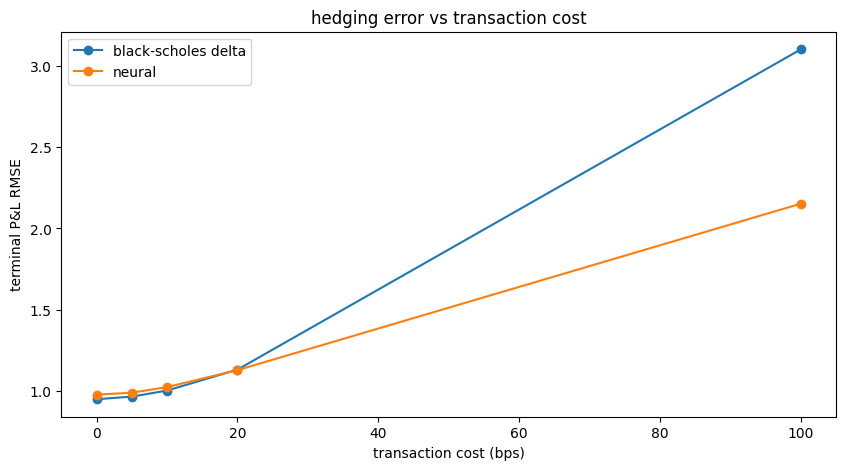

In [69]:
plt.figure(figsize=(10, 5))

for strategy in ["black-scholes delta", "neural"]:
    subset = results_df[results_df["strategy"] == strategy]

    plt.plot(
        subset["cost_bps"],
        subset["rmse"],
        marker="o",
        label=strategy
    )

plt.xlabel("transaction cost (bps)")
plt.ylabel("terminal P&L RMSE")
plt.title("hedging error vs transaction cost")

plt.legend()
plt.show()

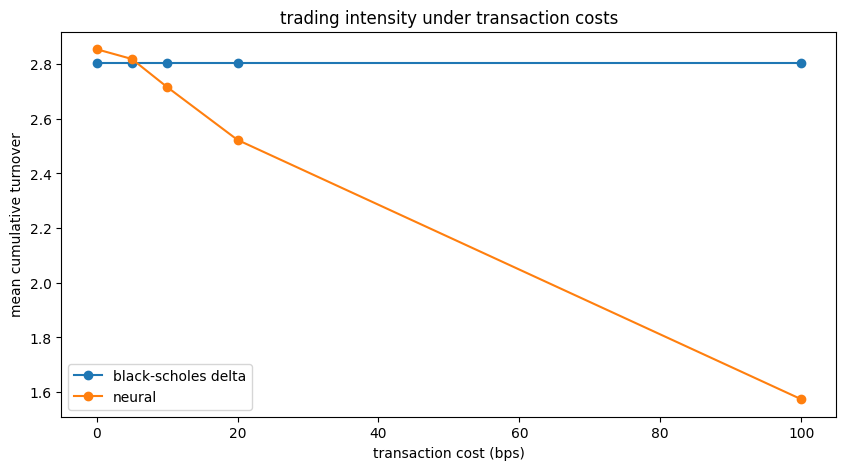

In [70]:
plt.figure(figsize=(10, 5))

for strategy in ["black-scholes delta", "neural"]:
    subset = results_df[results_df["strategy"] == strategy]

    plt.plot(
        subset["cost_bps"],
        subset["mean_share_turnover"],
        marker="o",
        label=strategy
    )

plt.xlabel("transaction cost (bps)")
plt.ylabel("mean cumulative turnover")
plt.title("trading intensity under transaction costs")

plt.legend()
plt.show()

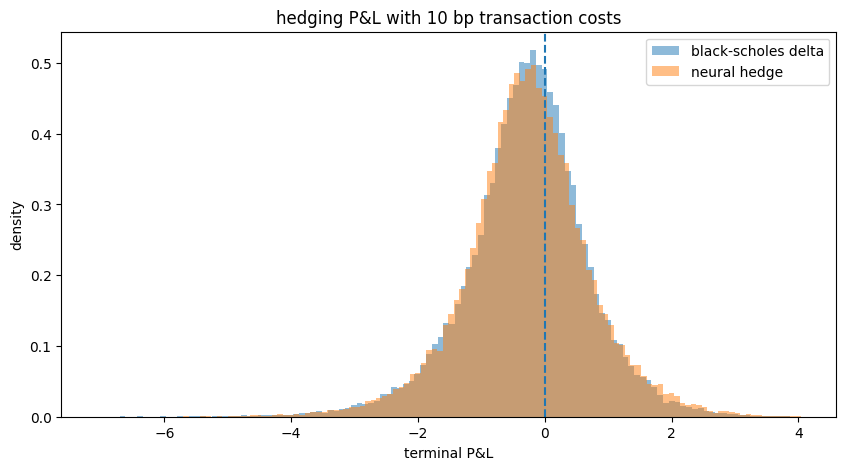

In [71]:
c_plot = 0.0010

nn_pnl = neural_results[c_plot]["pnl"]
bs_pnl = bs_results[c_plot]["pnl"]

plt.figure(figsize=(10, 5))

plt.hist(
    bs_pnl,
    bins=120,
    density=True,
    alpha=0.5,
    label="black-scholes delta"
)

plt.hist(
    nn_pnl,
    bins=120,
    density=True,
    alpha=0.5,
    label="neural hedge"
)

plt.axvline(0.0, linestyle="--")
plt.xlabel("terminal P&L")
plt.ylabel("density")
plt.title("hedging P&L with 10 bp transaction costs")

plt.legend()
plt.show()

In [72]:
previous_grid = torch.linspace(0.0, 1.0, 300, device=device)

S_eval = 100.0
t_eval = 0.5

tau_normalized = (T - t_eval) / T

In [73]:
def policy_vs_inventory(model):
    with torch.no_grad():
        log_moneyness = torch.full_like(previous_grid, np.log(S_eval / K))
        variance_feature = torch.full_like(previous_grid, sigma**2 / 0.04)
        tau_feature = torch.full_like(previous_grid, tau_normalized)

        state = torch.stack([
            log_moneyness,
            variance_feature,
            tau_feature,
            previous_grid
        ], dim=1)

        target = model(state)

    return target.cpu().numpy()

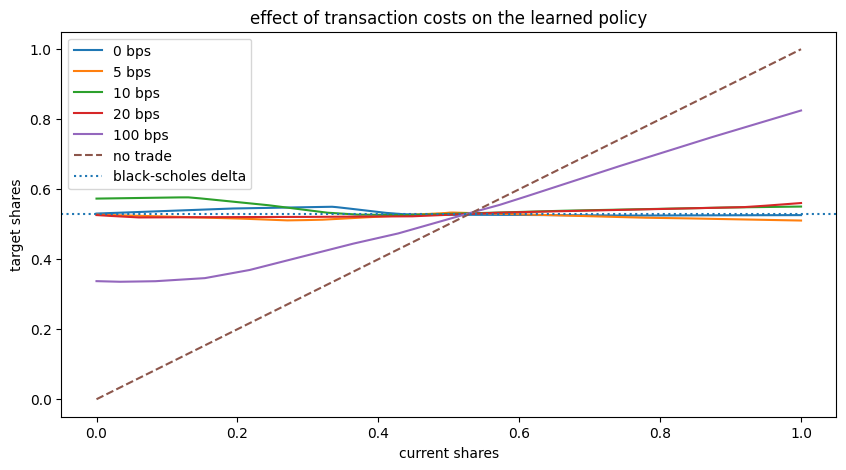

In [77]:
previous_np = previous_grid.cpu().numpy()

bs_target = black_scholes_delta(
    S=S_eval,
    K=K,
    sigma=sigma,
    T=T,
    t=t_eval,
    r=r
)

plt.figure(figsize=(10, 5))

for c in cost_rates:
    target = policy_vs_inventory(trained_models[c])

    plt.plot(
        previous_np,
        target,
        label=f"{c * 10_000:.0f} bps"
    )

plt.plot(
    previous_np,
    previous_np,
    linestyle="--",
    label="no trade"
)

plt.axhline(
    bs_target,
    linestyle=":",
    label="black-scholes delta"
)

plt.xlabel("current shares")
plt.ylabel("target shares")
plt.title("effect of transaction costs on the learned policy")

plt.legend()
plt.show()